## Early Stopping

In [5]:
from keras import Sequential
from keras.layers import Dense, Input
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from mlxtend.plotting import plot_decision_regions
from sklearn.datasets import make_circles

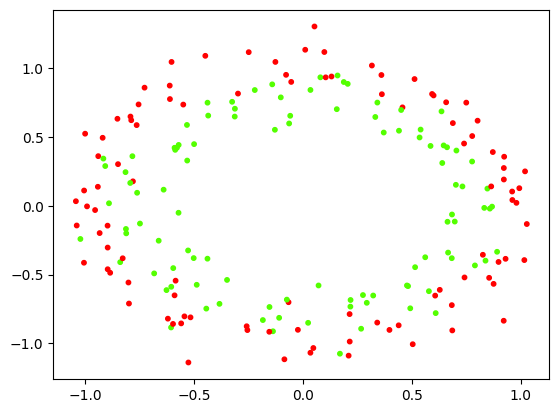

In [2]:
X,y = make_circles(200, noise=0.1)
plt.scatter(X[:,0],X[:,1],s=10,c=y,cmap='prism')

### Without EarlyStopping

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2)

In [10]:
model = Sequential()

model.add(Input(shape=(X.shape[1],)))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(X_train,y_train,batch_size=len(X_train), epochs=1000 ,verbose=1,validation_data=(X_test,y_test))

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5125 - loss: 0.6914 - val_accuracy: 0.4500 - val_loss: 0.6911
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.5125 - loss: 0.6912 - val_accuracy: 0.4500 - val_loss: 0.6911
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.5125 - loss: 0.6910 - val_accuracy: 0.4500 - val_loss: 0.6909
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.5125 - loss: 0.6908 - val_accuracy: 0.4500 - val_loss: 0.6908
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.5125 - loss: 0.6905 - val_accuracy: 0.4500 - val_loss: 0.6906
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.5125 - loss: 0.6903 - val_accuracy: 0.5000 - val_loss: 0.6904
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.5437 - loss: 0.6901 - val_accuracy: 0.5250 - val_loss: 0.6901
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.5375 - loss: 0.6899 - val_accuracy: 0.5250 - val

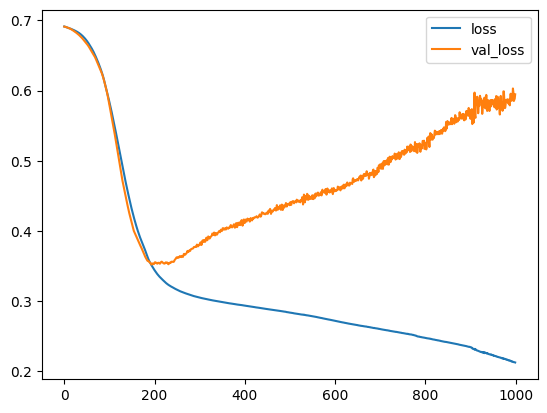

In [11]:
#plot
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()

In [12]:
callback = EarlyStopping(
    monitor= 'val_loss',
    min_delta=0.0001,
    patience=100,
    verbose=1,
    mode='auto',
    restore_best_weights=True
)

In [ ]:
model = Sequential()

model.add(Input(shape=(X.shape[1],)))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(
    X_train,y_train,batch_size=len(X_train),
    epochs=1000 ,
    verbose=1,
    validation_data=(X_test,y_test), 
    callbacks=callback
    )

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5188 - loss: 0.6949 - val_accuracy: 0.4500 - val_loss: 0.6948
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.4938 - loss: 0.6944 - val_accuracy: 0.5250 - val_loss: 0.6954
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.5000 - loss: 0.6939 - val_accuracy: 0.5000 - val_loss: 0.6959
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.4875 - loss: 0.6935 - val_accuracy: 0.4750 - val_loss: 0.6963
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.4938 - loss: 0.6932 - val_accuracy: 0.4250 - val_loss: 0.6966
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.5188 - loss: 0.6928 - val_accuracy: 0.3750 - val_loss: 0.6969
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.4688 - loss: 0.6926 - val_accuracy: 0.4250 - val_loss: 0.6973
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.4750 - loss: 0.6923 - val_accuracy: 0.3500 

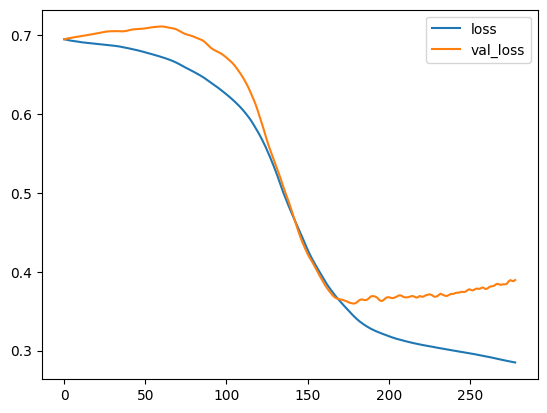

In [14]:
#plot
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()